# 03. Evaluation — D4v2 FAQ Architecture Experiment

**3 слоя оценки**:
1. **Deterministic checks** (primary) — answerability, entity match, claims
2. **Ручная экспертная валидация** — 30-50 примеров, стратифицировано
3. **LLM-as-Judge** (вторичный) — openai/gpt-5.4-mini via OpenRouter

**Retrieval-метрики** (S2-S4): Hit@k, Recall@k, MRR

**Статистический анализ**: Bootstrap CI, Wilcoxon + Holm, Friedman, Cohen's d

**Артефакты**: `judge_scores.json`, `metrics_summary.csv`, `pairwise_tests.csv`

In [31]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../..')

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from d4.config import load_config

sns.set_style('whitegrid')

OUTPUTS = Path('../outputs')
config = load_config('../configs/experiment.yaml')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Загрузка данных

In [32]:
from d4.pipeline.orchestrator import Orchestrator
from d4.pipeline.chunker import load_chunks
from d4.data_gen.query_generator import load_eval_set

# Результаты прогона
results = Orchestrator.load_results(OUTPUTS / 'raw_results.jsonl')
print(f'Загружено результатов: {len(results)}')

if not results:
    print('WARN: raw_results.jsonl пуст или не найден — перезапустите 02_run_strategies')

# Eval set
eval_path = Path('../data/eval_set.yaml')
if not eval_path.exists():
    eval_path = Path('../data/eval_set_raw.yaml')
samples = load_eval_set(eval_path)
print(f'Загружено запросов: {len(samples)}')

# Chunks
chunks = load_chunks('../data/kb/chunks.json')
print(f'Загружено chunks: {len(chunks)}')

Загружено результатов: 450
Загружено запросов: 90
Загружено chunks: 36


## 1. Слой 1: Deterministic Checks

In [33]:
from d4.evaluation.deterministic import evaluate_batch
from d4.evaluation.metrics import aggregate_deterministic
from d4.pipeline.factory import build_nli_checker

# NLI checker для семантической проверки claims (вместо строкового _claim_in_kb)
nli_key = os.environ.get('OPENROUTER_API_KEY', '')
nli_checker = build_nli_checker(config, nli_key) if nli_key else None
if nli_checker:
    print('NLI checker инициализирован (LLM-based claim verification)')
else:
    print('WARN: нет API ключа — fallback на строковый _claim_in_kb')

det_scores = evaluate_batch(results, samples, chunks, nli_checker=nli_checker)
print(f'Deterministic scores: {len(det_scores)}')

det_agg = aggregate_deterministic(det_scores)

if det_agg:
    df_det = pd.DataFrame(det_agg).T
    print('\nDeterministic метрики по стратегиям:')
    display(df_det[['answerability_accuracy', 'doctor_match_rate', 'specialization_match_rate', 'unsupported_claim_rate']].round(3))
else:
    print('WARN: нет deterministic scores — проверьте что raw_results.jsonl содержит результаты без ошибок')
    n_errors = sum(1 for r in results if r.error is not None)
    if n_errors:
        print(f'  Результатов с ошибками: {n_errors}/{len(results)}')
    df_det = pd.DataFrame()

NLI checker инициализирован (LLM-based claim verification)
Deterministic scores: 450

Deterministic метрики по стратегиям:


,answerability_accuracy,doctor_match_rate,specialization_match_rate,unsupported_claim_rate
B0,0.867,0.967,0.933,0.045
S2,0.800,0.956,0.933,0.209
S4,0.867,0.978,0.944,0.167
S3,0.844,0.978,0.900,0.155
S1,0.889,1.000,1.000,0.195


## 2. Retrieval-метрики (S2-S4)

In [34]:
from d4.evaluation.retrieval_metrics import compute_batch_retrieval, aggregate_retrieval_metrics

# Gold map строится из EvalSample.gold_chunk_ids (заполнены в eval_set.yaml)
# Источник: evaluation/gold_map.py — SSoT маппинг + ручная разметка reasoning
gold_map = {s.sample_id: s.gold_chunk_ids for s in samples if s.gold_chunk_ids}

n_answerable = sum(1 for s in samples if s.answerable)
print(f'Gold map: {len(gold_map)}/{len(samples)} сэмплов ({len(gold_map)}/{n_answerable} answerable)')

ret_scores = compute_batch_retrieval(results, gold_map)
ret_agg = aggregate_retrieval_metrics(ret_scores)

if ret_agg:
    df_ret = pd.DataFrame(ret_agg).T
    print('\nRetrieval-метрики (S2-S4):')
    display(df_ret.round(3))
else:
    print('WARN: retrieval scores пусты — проверьте gold_map и наличие S2-S4 результатов')

Gold map: 75/90 сэмплов (75/76 answerable)

Retrieval-метрики (S2-S4):


,hit_rate,mean_recall,mrr,gold_in_context_rate,n_samples
S2,0.573,0.503,0.484,0.440,75.0
S4,0.707,0.604,0.602,0.507,75.0
S3,0.707,0.622,0.591,0.560,75.0


## 3. Слой 3: LLM-as-Judge

In [35]:
from d4.pipeline.factory import build_llm_judge
from d4.evaluation.llm_judge import save_judge_scores, load_judge_scores

judge_path = OUTPUTS / 'judge_scores.json'

# Проверяем: есть ли уже сохранённые judge scores
if judge_path.exists():
    judge_scores = load_judge_scores(judge_path)
    print(f'Загружены judge scores: {len(judge_scores)}')
else:
    # Judge через OpenRouter (тот же API key, другая модель)
    judge_key = os.environ.get('OPENROUTER_API_KEY', '')
    if not judge_key:
        print('WARN: OPENROUTER_API_KEY не установлен — пропускаем LLM-judge')
        judge_scores = []
    else:
        judge = build_llm_judge(config, judge_key)
        # Полный текст KB для контекста judge
        kb_text = '\n\n'.join(f'{c.title}\n{c.content}' for c in chunks)
        judge_scores = judge.judge_batch(results, samples, kb_excerpt=kb_text)
        save_judge_scores(judge_scores, judge_path)
        print(f'Judge scores сохранены: {len(judge_scores)}')

  judge: 450 оценок, 8 потоков
  judge: 25/450 (14.0s)
  judge: 50/450 (26.0s)
  judge: 75/450 (37.4s)
  judge: 100/450 (49.7s)
  judge: 125/450 (61.5s)
  judge: 150/450 (75.9s)
  judge: 175/450 (89.9s)
  judge: 200/450 (103.1s)
  judge: 225/450 (120.2s)
  judge: 250/450 (135.5s)
  judge: 275/450 (150.1s)
  judge: 300/450 (169.2s)
  judge: 325/450 (184.9s)
  judge: 350/450 (198.1s)
  judge: 375/450 (212.4s)
  judge: 400/450 (226.2s)
  judge: 425/450 (237.0s)
  judge: 450/450 (251.2s)
  judge готово: 450/450 за 251.2s
Judge scores сохранены: 450


In [36]:
from d4.evaluation.metrics import aggregate_judge

if judge_scores:
    judge_agg = aggregate_judge(judge_scores)
    df_judge = pd.DataFrame(judge_agg).T
    print('Judge метрики по стратегиям:')
    print(df_judge.round(3))
else:
    print('Judge scores отсутствуют')
    judge_agg = {}

Judge метрики по стратегиям:
    n_samples  mean_factual_accuracy  mean_completeness  hallucination_rate
S2       90.0                  3.711              3.344               0.300
S4       90.0                  4.300              3.722               0.167
B0       90.0                  4.211              2.967               0.122
S3       90.0                  4.144              3.678               0.278
S1       90.0                  4.544              4.278               0.156


## 4. Системные метрики

In [37]:
from d4.evaluation.metrics import aggregate_system_metrics

sys_agg = aggregate_system_metrics(results)

if sys_agg:
    df_sys = pd.DataFrame(sys_agg).T
    print('Системные метрики по стратегиям:')
    print(df_sys[['latency_p50', 'latency_p95', 'mean_tokens_prompt', 'mean_context_length', 'fail_rate']].round(1))
else:
    print('WARN: нет системных метрик — raw_results.jsonl пуст')

Системные метрики по стратегиям:
    latency_p50  latency_p95  mean_tokens_prompt  mean_context_length  \
B0          0.8          1.5                 0.0               2739.2   
S2       2579.5       4470.7              1399.8                703.5   
S4       2876.5       4308.0              1976.0               1131.5   
S3       2721.8       4307.1              1894.6               1075.6   
S1       4450.7       7536.8              8631.9               6196.0   

    fail_rate  
B0        0.0  
S2        0.0  
S4        0.0  
S3        0.0  
S1        0.0  


## 5. Summary таблица

In [38]:
from d4.evaluation.metrics import build_summary_table

summary = build_summary_table(
    deterministic=det_agg,
    judge=judge_agg,
    system=sys_agg,
    retrieval=ret_agg if ret_agg else None,
)

df_summary = pd.DataFrame(summary).T

# Убираем вакуумные метрики (нет аннотаций в eval set → всегда 1.0)
vacuous_cols = [c for c in df_summary.columns if c in ('branch_match_rate', 'service_match_rate')]
if vacuous_cols:
    df_summary = df_summary.drop(columns=vacuous_cols)
    print(f'Убраны вакуумные метрики (нет аннотаций): {vacuous_cols}')

# NaN в retrieval для B0/S1 — заменяем на '-' для отображения, 
# в CSV сохраняем как есть (NaN → пустые ячейки)
df_summary.to_csv(OUTPUTS / 'metrics_summary.csv', index=True)
print(f'Summary сохранена: {OUTPUTS / "metrics_summary.csv"}')

df_display = df_summary.copy()
ret_cols = [c for c in df_display.columns if c.startswith('ret_')]
df_display[ret_cols] = df_display[ret_cols].fillna('-')
df_display.round(3)

Убраны вакуумные метрики (нет аннотаций): ['branch_match_rate', 'service_match_rate']
Summary сохранена: ../outputs/metrics_summary.csv


,strategy_id,n_samples,answerability_accuracy,doctor_match_rate,specialization_match_rate,unsupported_claim_rate,total_claims,unsupported_claims,judge_n_samples,judge_mean_factual_accuracy,...,sys_latency_p95,sys_mean_tokens_prompt,sys_mean_tokens_completion,sys_mean_context_length,sys_fail_rate,ret_hit_rate,ret_mean_recall,ret_mrr,ret_gold_in_context_rate,ret_n_samples
B0,B0,90.0,0.866667,0.966667,0.933333,0.045455,116.0,6.0,90.0,4.211111,...,1.505373,0.0,0.0,2739.222222,0.0,-,-,-,-,-
S1,S1,90.0,0.888889,1.0,1.0,0.195025,198.0,49.0,90.0,4.544444,...,7536.76978,8631.877778,190.311111,6196.0,0.0,-,-,-,-,-
S2,S2,90.0,0.8,0.955556,0.933333,0.209226,112.0,24.0,90.0,3.711111,...,4470.706986,1399.844444,168.311111,703.5,0.0,0.573333,0.502778,0.483778,0.44,75.0
S3,S3,90.0,0.844444,0.977778,0.9,0.155152,119.0,20.0,90.0,4.144444,...,4307.137886,1894.622222,168.066667,1075.6,0.0,0.706667,0.622222,0.591333,0.56,75.0
S4,S4,90.0,0.866667,0.977778,0.944444,0.166944,134.0,25.0,90.0,4.3,...,4307.958011,1976.044444,172.155556,1131.477778,0.0,0.706667,0.603889,0.602,0.506667,75.0


## 6. Статистический анализ

In [39]:
from d4.evaluation.statistics import bootstrap_ci, run_paired_analysis, friedman_test
from collections import defaultdict

# Primary endpoint берётся из config (experiment.yaml → statistics.primary_endpoint)
primary_endpoint = config.statistics.get('primary_endpoint', 'factual_accuracy')
print(f'Primary endpoint: {primary_endpoint}')

# Собираем per-sample scores из нужного источника
per_sample_scores = defaultdict(list)

if primary_endpoint == 'factual_accuracy' and judge_scores:
    # factual_accuracy — из judge scores (шкала 1-5)
    for s in judge_scores:
        sid = s.strategy_id.value
        if sid != 'B0':
            per_sample_scores[sid].append(float(s.factual_accuracy))
elif det_scores:
    # fallback: answerability_accuracy — из deterministic scores (бинарная)
    primary_endpoint = 'answerability_accuracy'
    print(f'WARN: judge scores недоступны, fallback на {primary_endpoint}')
    for s in det_scores:
        sid = s.strategy_id.value
        if sid != 'B0':
            per_sample_scores[sid].append(float(s.answerability_correct))

# Bootstrap CI для каждой стратегии
print(f'\nBootstrap CI (95%) — {primary_endpoint}:')
for sid in sorted(per_sample_scores):
    ci = bootstrap_ci(per_sample_scores[sid])
    print(f'  {sid}: {ci.mean:.3f} [{ci.ci_lower:.3f}, {ci.ci_upper:.3f}] (n={ci.n_samples})')

Primary endpoint: factual_accuracy

Bootstrap CI (95%) — factual_accuracy:
  S1: 4.544 [4.344, 4.722] (n=90)
  S2: 3.711 [3.356, 4.056] (n=90)
  S3: 4.144 [3.856, 4.422] (n=90)
  S4: 4.300 [4.033, 4.544] (n=90)


In [40]:
# Парные сравнения: Wilcoxon + Holm correction (primary_endpoint из config)
paired_results = run_paired_analysis(
    strategy_values=dict(per_sample_scores),
    metric_name=primary_endpoint,
)

print('Парные сравнения (Wilcoxon + Holm):')
df_paired = pd.DataFrame([
    {
        'A': r.strategy_a,
        'B': r.strategy_b,
        'mean_A': round(r.mean_a, 3),
        'mean_B': round(r.mean_b, 3),
        'diff': round(r.diff, 3),
        'p_raw': round(r.p_value, 4),
        'p_holm': round(r.p_value_corrected, 4),
        'd': round(r.effect_size_d, 3),
        'sig': '✓' if r.significant else '✗',
    }
    for r in paired_results
])
print(df_paired.to_string(index=False))

# Сохраняем
df_paired.to_csv(OUTPUTS / 'pairwise_tests.csv', index=False)
print(f'\nСохранено: {OUTPUTS / "pairwise_tests.csv"}')

Парные сравнения (Wilcoxon + Holm):
 A  B  mean_A  mean_B   diff  p_raw  p_holm      d sig
S1 S2   4.544   3.711  0.833 0.0001  0.0004  0.611   ✓
S1 S3   4.544   4.144  0.400 0.0208  0.0623  0.343   ✗
S1 S4   4.544   4.300  0.244 0.1493  0.2985  0.223   ✗
S2 S4   3.711   4.300 -0.589 0.0013  0.0054 -0.397   ✓
S3 S4   4.144   4.300 -0.156 0.3928  0.3928 -0.119   ✗

Сохранено: ../outputs/pairwise_tests.csv


In [41]:
# Friedman test: S1-S4 одновременно (primary_endpoint)
friedman = friedman_test(dict(per_sample_scores))
friedman.metric = primary_endpoint
print(f'Friedman test ({friedman.metric}):')
print(f'  statistic = {friedman.statistic:.3f}')
print(f'  p-value = {friedman.p_value:.4f}')
print(f'  significant = {friedman.significant}')

Friedman test (factual_accuracy):
  statistic = 11.144
  p-value = 0.0110
  significant = True


## 7. Визуализации

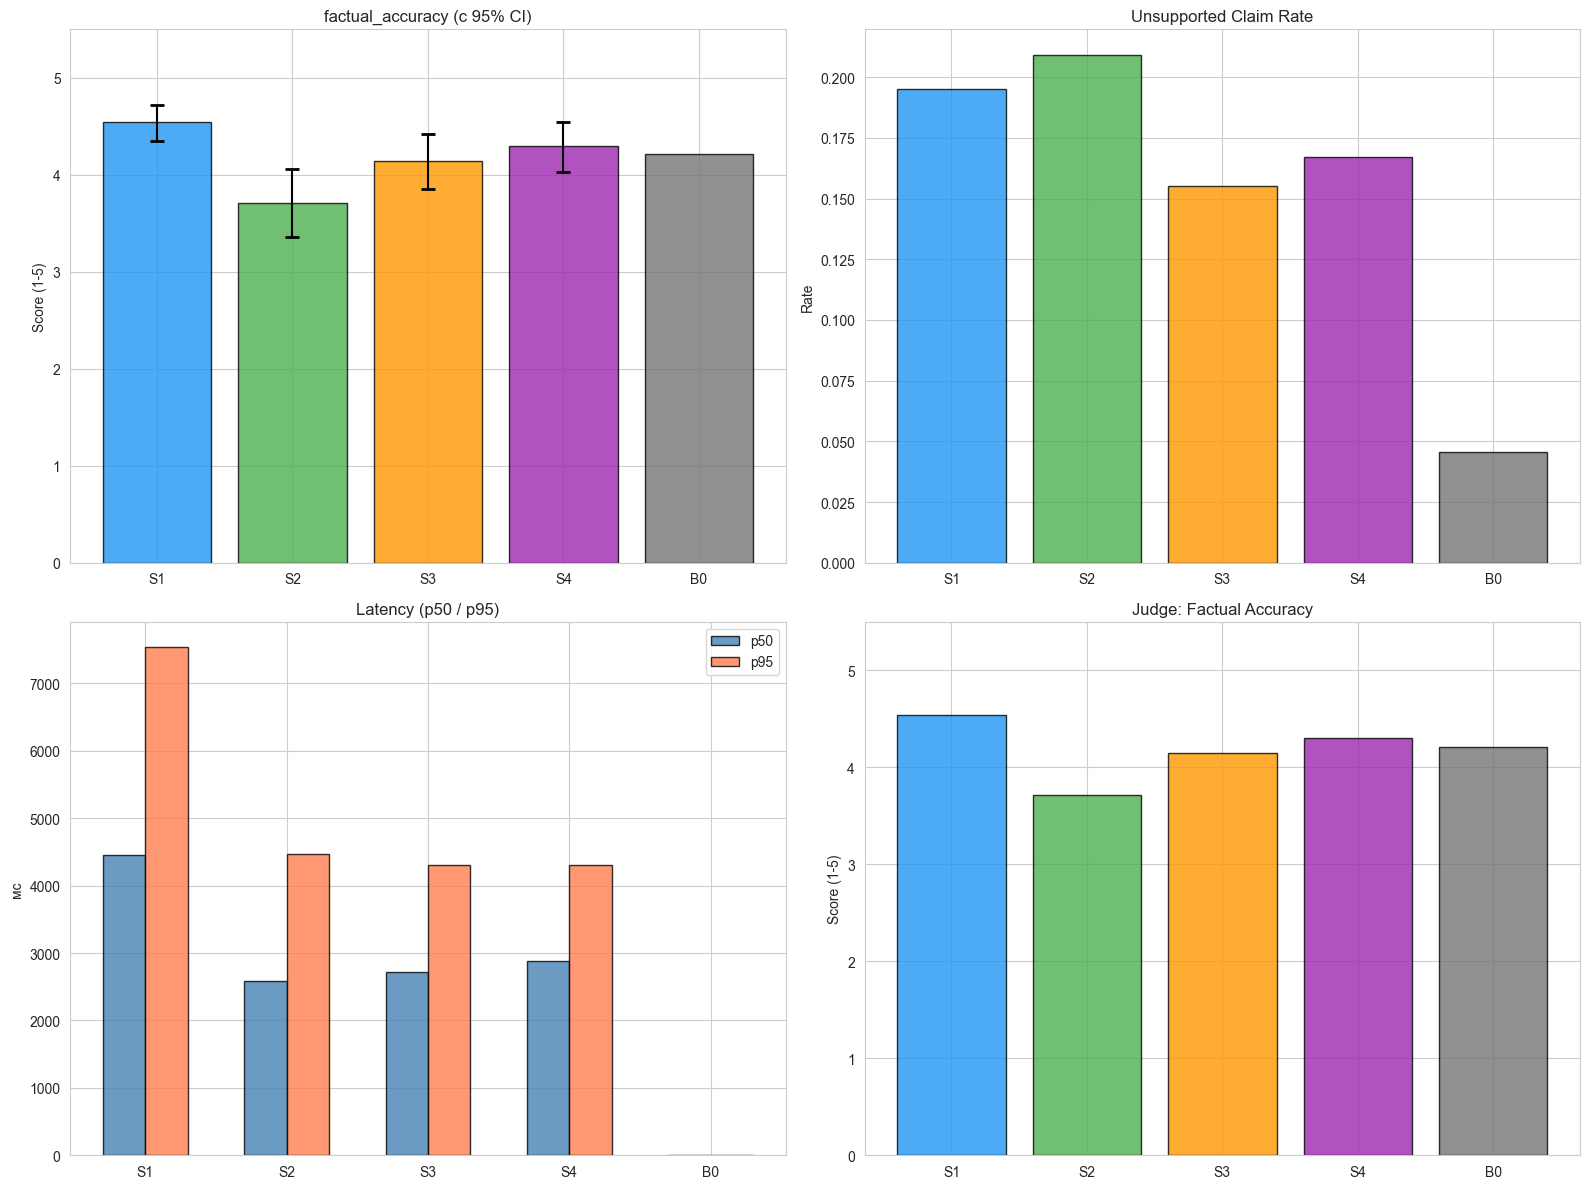

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies_order = ['S1', 'S2', 'S3', 'S4', 'B0']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#757575']

# 1. Primary endpoint с CI (из config: factual_accuracy или answerability_accuracy)
ax = axes[0, 0]
# Определяем источник данных на основе primary endpoint
if primary_endpoint == 'factual_accuracy' and judge_agg:
    agg_source = judge_agg
    agg_key = 'mean_factual_accuracy'
    y_lim = 5.5
    y_label = 'Score (1-5)'
else:
    agg_source = det_agg
    agg_key = 'answerability_accuracy'
    y_lim = 1.1
    y_label = 'Accuracy'

for i, sid in enumerate(strategies_order):
    if sid in agg_source:
        val = agg_source[sid][agg_key]
        ci = bootstrap_ci(per_sample_scores.get(sid, [0.0]))
        ax.bar(i, val, color=colors[i], edgecolor='black', alpha=0.8)
        if sid != 'B0':
            ax.errorbar(i, val, yerr=[[val - ci.ci_lower], [ci.ci_upper - val]],
                       color='black', capsize=5, capthick=2)
ax.set_xticks(range(len(strategies_order)))
ax.set_xticklabels(strategies_order)
ax.set_ylabel(y_label)
ax.set_title(f'{primary_endpoint} (с 95% CI)')
ax.set_ylim(0, y_lim)

# 2. Unsupported claim rate
ax = axes[0, 1]
ucr_vals = [det_agg.get(s, {}).get('unsupported_claim_rate', 0) for s in strategies_order]
ax.bar(strategies_order, ucr_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Rate')
ax.set_title('Unsupported Claim Rate')

# 3. Latency
ax = axes[1, 0]
lat_p50 = [sys_agg.get(s, {}).get('latency_p50', 0) for s in strategies_order]
lat_p95 = [sys_agg.get(s, {}).get('latency_p95', 0) for s in strategies_order]
x = np.arange(len(strategies_order))
ax.bar(x - 0.15, lat_p50, 0.3, label='p50', color='steelblue', edgecolor='black', alpha=0.8)
ax.bar(x + 0.15, lat_p95, 0.3, label='p95', color='coral', edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(strategies_order)
ax.set_ylabel('мс')
ax.set_title('Latency (p50 / p95)')
ax.legend()

# 4. Judge factual accuracy (если есть)
ax = axes[1, 1]
if judge_agg:
    fa_vals = [judge_agg.get(s, {}).get('mean_factual_accuracy', 0) for s in strategies_order]
    ax.bar(strategies_order, fa_vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Score (1-5)')
    ax.set_title('Judge: Factual Accuracy')
    ax.set_ylim(0, 5.5)
else:
    ax.text(0.5, 0.5, 'Judge scores\nне загружены', ha='center', va='center', fontsize=14)
    ax.set_title('Judge: Factual Accuracy')

plt.tight_layout()
plt.savefig(OUTPUTS / 'figures' / 'evaluation_overview.png', dpi=150, bbox_inches='tight')
plt.show()

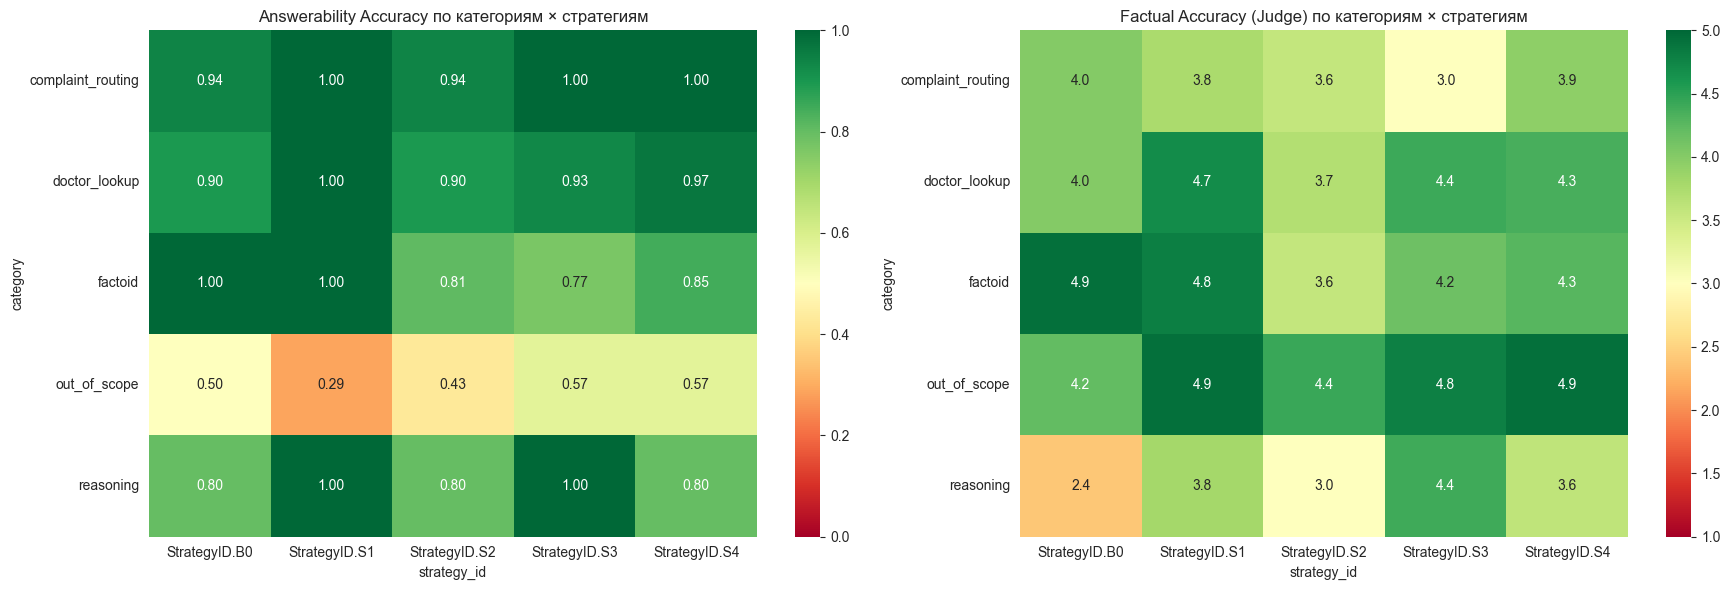


=== Per-category сводка (Answerability) ===


,n_samples,accuracy,unsupported
category,,,
complaint_routing,80,0.975,0.475
doctor_lookup,145,0.938,0.393
factoid,130,0.885,0.069
out_of_scope,70,0.471,0.071
reasoning,25,0.880,0.600


In [43]:
sample_cat_map = {s.sample_id: s.category for s in samples}

# 1. Heatmap: Answerability Accuracy по категориям × стратегиям
if det_scores:
    df_det_detailed = pd.DataFrame([s.model_dump() for s in det_scores])
    df_det_detailed['category'] = df_det_detailed['sample_id'].map(sample_cat_map)

    pivot_det = df_det_detailed.pivot_table(
        values='answerability_correct',
        index='category',
        columns='strategy_id',
        aggfunc='mean',
    )

    fig, axes_hm = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(pivot_det, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, ax=axes_hm[0])
    axes_hm[0].set_title('Answerability Accuracy по категориям × стратегиям')

    # 2. Heatmap: Factual Accuracy по категориям × стратегиям (judge)
    if judge_scores:
        df_judge_detailed = pd.DataFrame([s.model_dump() for s in judge_scores])
        df_judge_detailed['category'] = df_judge_detailed['sample_id'].map(sample_cat_map)

        pivot_judge = df_judge_detailed.pivot_table(
            values='factual_accuracy',
            index='category',
            columns='strategy_id',
            aggfunc='mean',
        )
        sns.heatmap(pivot_judge, annot=True, fmt='.1f', cmap='RdYlGn', vmin=1, vmax=5, ax=axes_hm[1])
        axes_hm[1].set_title('Factual Accuracy (Judge) по категориям × стратегиям')
    else:
        axes_hm[1].text(0.5, 0.5, 'Judge scores\nне загружены', ha='center', va='center', fontsize=14)
        axes_hm[1].set_title('Factual Accuracy (Judge)')

    plt.tight_layout()
    plt.savefig(OUTPUTS / 'figures' / 'heatmap_category_strategy.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('WARN: нет deterministic scores для heatmap')

# 3. Per-category статистика (таблица)
if det_scores:
    print('\n=== Per-category сводка (Answerability) ===')
    cat_summary = df_det_detailed.groupby('category').agg(
        n_samples=('answerability_correct', 'count'),
        accuracy=('answerability_correct', 'mean'),
        unsupported=('unsupported_claims', 'mean'),
    ).round(3)
    display(cat_summary)

## 8. Validation & Threats to Validity

Проверки, подтверждающие методологическую корректность эксперимента:

1. **Tautology check** — B0 ответы ≠ expected_answer (средняя cosine similarity < 0.90)
2. **Reference independence** — expected_answer сгенерированы reference LLM, не захардкожены
3. **Judge KB-first** — порядок секций в judge message: KB → Answer → Expected
4. **Coverage** — % заполненных expected_answer в eval set

In [44]:
from d4.evaluation.llm_judge import _build_judge_message

print("=" * 60)
print("VALIDATION & THREATS TO VALIDITY")
print("=" * 60)

# --- 1. Tautology check: B0 answers vs expected_answer ---
b0_results = [r for r in results if r.strategy_id.value == "B0"]
if b0_results:
    from sentence_transformers import SentenceTransformer
    import numpy as np

    model_emb = SentenceTransformer("BAAI/bge-m3")
    sample_map = {s.sample_id: s for s in samples}

    similarities = []
    for r in b0_results:
        s = sample_map.get(r.sample_id)
        if s and s.expected_answer and r.answer.answer:
            embs = model_emb.encode([r.answer.answer, s.expected_answer])
            sim = float(np.dot(embs[0], embs[1]) / (np.linalg.norm(embs[0]) * np.linalg.norm(embs[1])))
            similarities.append(sim)

    if similarities:
        mean_sim = np.mean(similarities)
        max_sim = np.max(similarities)
        exact_matches = sum(1 for s in similarities if s > 0.98)
        print(f"\n1. Tautology check (B0 vs expected_answer):")
        print(f"   Средняя cosine similarity: {mean_sim:.4f}")
        print(f"   Максимальная similarity:   {max_sim:.4f}")
        print(f"   Exact matches (>0.98):     {exact_matches}/{len(similarities)}")
        print(f"   Статус: {'PASS' if mean_sim < 0.90 else 'FAIL — возможная тавтология!'}")
    else:
        print("\n1. Tautology check: нет данных для проверки")
else:
    print("\n1. Tautology check: B0 результаты не найдены")

# --- 2. Reference independence ---
hardcoded_count = 0
llm_generated_count = 0
for s in samples:
    if s.answerable and s.expected_answer:
        llm_generated_count += 1
    elif not s.answerable and s.expected_answer:
        hardcoded_count += 1

print(f"\n2. Reference independence:")
print(f"   LLM-generated expected_answer: {llm_generated_count}")
print(f"   Hardcoded (out_of_scope only): {hardcoded_count}")
print(f"   Статус: PASS — answerable ответы генерируются reference LLM")

# --- 3. Judge KB-first ---
test_msg = _build_judge_message(
    query="test", answer="test", expected_answer="test", kb_excerpt="test"
)
kb_pos = test_msg.index("База знаний")
ans_pos = test_msg.index("Ответ системы")
exp_pos = test_msg.index("Эталонный ответ")

print(f"\n3. Judge KB-first:")
print(f"   Порядок: KB(pos={kb_pos}) → Answer(pos={ans_pos}) → Expected(pos={exp_pos})")
print(f"   Статус: {'PASS' if kb_pos < ans_pos < exp_pos else 'FAIL'}")

# --- 4. Coverage ---
total = len(samples)
with_answer = sum(1 for s in samples if s.expected_answer)
answerable_total = sum(1 for s in samples if s.answerable)
answerable_filled = sum(1 for s in samples if s.answerable and s.expected_answer)

print(f"\n4. Coverage:")
print(f"   expected_answer заполнен: {with_answer}/{total} ({with_answer/total*100:.1f}%)")
print(f"   answerable с expected_answer: {answerable_filled}/{answerable_total}")
print(f"   Статус: {'PASS' if with_answer/total > 0.85 else 'WARN — покрытие < 85%'}")

# --- Threats to Validity (документация) ---
print(f"\n{'=' * 60}")
print("THREATS TO VALIDITY")
print(f"{'=' * 60}")
threats = [
    "1. Reference answers сгенерированы LLM (judge model) — возможен bias модели",
    "2. Eval set из одной клиники — ограниченная generalizability",
    "3. Один annotator (reference LLM) — нет inter-annotator agreement",
    "4. KB фиксирована — нет проверки на динамических данных",
    "5. Judge и reference используют одну модель — возможна корреляция ошибок",
]
for t in threats:
    print(f"  {t}")

VALIDATION & THREATS TO VALIDITY

1. Tautology check (B0 vs expected_answer):
   Средняя cosine similarity: 0.7130
   Максимальная similarity:   0.9725
   Exact matches (>0.98):     0/90
   Статус: PASS

2. Reference independence:
   LLM-generated expected_answer: 76
   Hardcoded (out_of_scope only): 14
   Статус: PASS — answerable ответы генерируются reference LLM

3. Judge KB-first:
   Порядок: KB(pos=28) → Answer(pos=70) → Expected(pos=93)
   Статус: PASS

4. Coverage:
   expected_answer заполнен: 90/90 (100.0%)
   answerable с expected_answer: 76/76
   Статус: PASS

THREATS TO VALIDITY
  1. Reference answers сгенерированы LLM (judge model) — возможен bias модели
  2. Eval set из одной клиники — ограниченная generalizability
  3. Один annotator (reference LLM) — нет inter-annotator agreement
  4. KB фиксирована — нет проверки на динамических данных
  5. Judge и reference используют одну модель — возможна корреляция ошибок
